<a href="https://colab.research.google.com/github/madhura2024/practice/blob/main/practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)
Trades date range: 2023-03-28 to 2025-06-15
Sent date range: 2018-02-01 to 2025-05-02
Merged rows: 7
PnL by sentiment class classification
Extreme Greed    1.769655e+05
Fear             6.699925e+06
Greed            1.063206e+06
Neutral          1.587424e+05
Name: daily_pnl, dtype: float64
Correlation between PnL & sentiment               value  daily_pnl
value      1.000000  -0.452662
daily_pnl -0.452662   1.000000


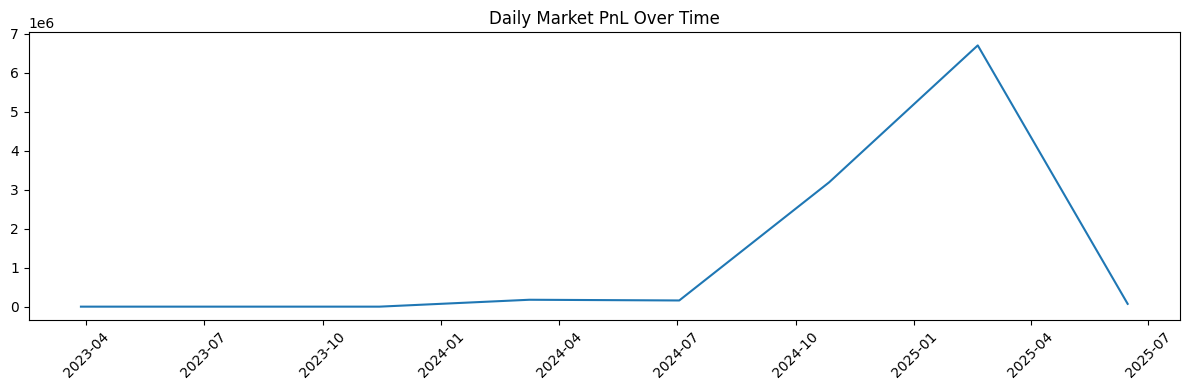

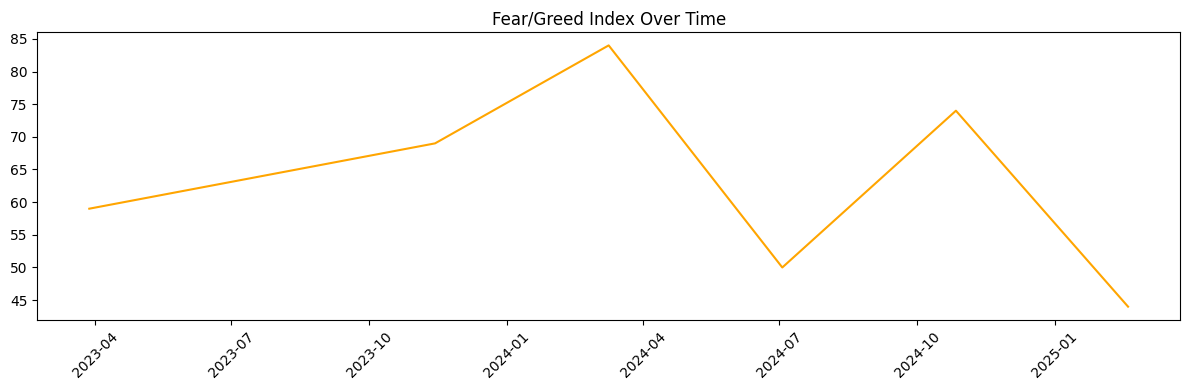

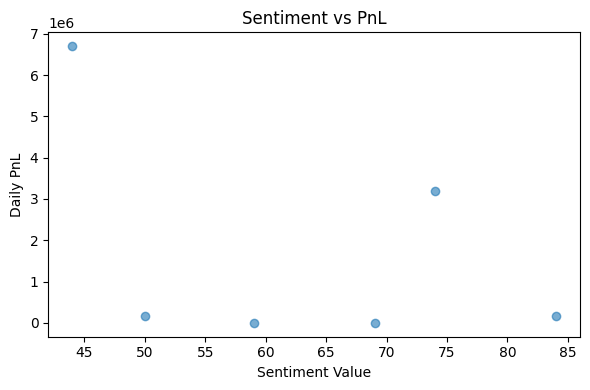

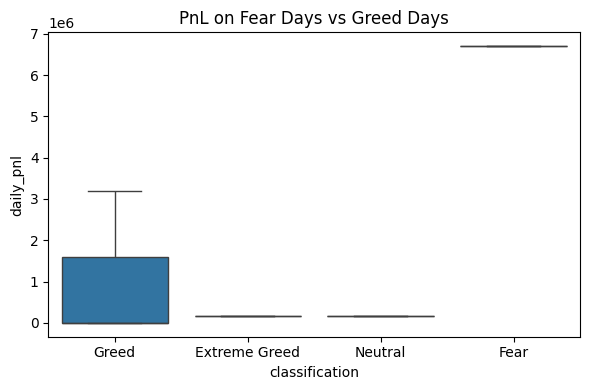

Correlation with lag sentiment                 prev_sentiment  daily_pnl
prev_sentiment        1.000000   0.153849
daily_pnl             0.153849   1.000000
conclution
Total days 7
Direct sentiment vs PnL -0.4526619660480214
sentiment effect 0.15384948353076197
Average Greedatte PnL 1063205.5117920002
Average Feardate PnL 6699925.190574


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import warnings
# warnings.filterwarnings("ignore")
trades = pd.read_csv("historical_data.csv")
sent = pd.read_csv("fear_greed_index.csv")
print("Trades shape:", trades.shape)
print("Sentiment shape:", sent.shape)

#lower them rule
trades.columns = trades.columns.str.lower()
sent.columns = sent.columns.str.lower()

#fix time ....
if 'timestamp_ist' in trades.columns:
    trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], unit='ms', errors='coerce')
    trades['date'] = trades['timestamp_ist'].dt.date

elif 'timestamp' in trades.columns:
    trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms', errors='coerce')
    trades['date'] = trades['timestamp'].dt.date

else:
    raise ValueError("Couldn't find a proper timestamp column in the trades file")


#date fix error
sent['date'] = pd.to_datetime(sent['date']).dt.date
trades['date'] = pd.to_datetime(trades['date']).dt.date
sent['date'] = pd.to_datetime(sent['date']).dt.date

# remove duplicates
sent = sent.drop_duplicates(subset=['date'], keep='last')

pnl_col = None
for col in trades.columns:
    if "pnl" in col:
        pnl_col = col
        break

if pnl_col is None:
    raise ValueError("No PnL column available in the trades dataset")

daily_market = trades.groupby('date')[pnl_col].sum().reset_index()
daily_market = daily_market.rename(columns={pnl_col: "daily_pnl"})

print("Trades date range:", daily_market['date'].min(), "to", daily_market['date'].max())
print("Sent date range:", sent['date'].min(), "to", sent['date'].max())

#to compare we gotta merge
merged = pd.merge(
    daily_market,
    sent[['date','value','classification']],
    on='date',
    how='left'
)
print("Merged rows:", len(merged))


#from here main thing beegin
pnl_by_sentiment = merged.groupby('classification')['daily_pnl'].mean()
print("PnL by sentiment class", pnl_by_sentiment)

# Correlation between daily pnl and sentiment value.
corr = merged[['value','daily_pnl']].corr()
print("Correlation between PnL & sentiment", corr)


# 6. Graph
plt.figure(figsize=(12,4))
plt.plot(merged['date'], merged['daily_pnl'])
plt.title("Daily Market PnL Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sentiment over time
plt.figure(figsize=(12,4))
plt.plot(merged['date'], merged['value'], color='orange')
plt.title("Fear/Greed Index Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Scatter plot does higher greed mean more profit?
plt.figure(figsize=(6,4))
plt.scatter(merged['value'], merged['daily_pnl'], alpha=0.6)
plt.xlabel("Sentiment Value")
plt.ylabel("Daily PnL")
plt.title("Sentiment vs PnL")
plt.tight_layout()
plt.show()

# Boxplot: PnL on Fear days vs Greed days.
plt.figure(figsize=(6,4))
if merged['classification'].notna().sum() == 0:
    print("No sentiment classes available — skipping boxplot.")
else:
    sns.boxplot(x='classification', y='daily_pnl', data=merged.dropna(subset=['classification']))
    plt.title("PnL on Fear Days vs Greed Days")
    plt.tight_layout()
    plt.show()

# Adding previous day's sentiment
merged['prev_sentiment'] = merged['value'].shift(1)

# Testing correlation again
lag_corr = merged[['prev_sentiment','daily_pnl']].corr()

print("Correlation with lag sentiment", lag_corr)
print("conclution")
print("Total days", len(merged))
print("Direct sentiment vs PnL", corr.get('value', {}).get('daily_pnl', None))
print("sentiment effect", lag_corr.get('prev_sentiment', {}).get('daily_pnl', None))
print("Average Greedatte PnL", pnl_by_sentiment.get("Greed", "N/A"))
print("Average Feardate PnL", pnl_by_sentiment.get("Fear", "N/A"))
